# Diabetes Dataset: Data Preparation

This notebook prepares the Pima Indians Diabetes dataset so it is ready for
training a neural network. It does **not** build or train any model.

By the end of this notebook we will have a clean, feature-engineered,
scaled dataset saved to disk, ready to be loaded in the next notebook
(`02_ann_training.ipynb`).

**What this notebook covers:**
1. Load and inspect the data
2. Explore the data visually (EDA)
3. Fix impossible values (zeros that should be missing)
4. Engineer a few extra features
5. Split the data into train / validation / test sets
6. Scale the features and save everything to disk


## Step 0: Get the dataset

Run one of these in a terminal before starting (only needs to be done once):

```bash
kaggle datasets download -d uciml/pima-indians-diabetes-database
unzip pima-indians-diabetes-database.zip
```

Or, without Kaggle:

```bash
wget https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv
```

Either way you should end up with a file called `diabetes.csv` in the same folder as this notebook.

## Step 1: Import libraries

Just the basics for loading data, plotting, and saving files.

In [ ]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fixing the random seed makes our split reproducible: everyone who runs
# this notebook gets the same train / val / test rows.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## Step 2: Load the data and take a first look

Before doing anything else, we always want to answer:
- How many rows and columns do we have?
- Are there duplicate rows?
- Are there missing values?
- What do the values actually look like?

In [2]:
df = pd.read_csv('diabetes.csv')

print(f"Shape:         {df.shape}")
print(f"Duplicates:    {df.duplicated().sum()}")
print(f"Missing (NaN): {df.isnull().sum().sum()}")

df.head()


Shape:         (768, 9)
Duplicates:    0
Missing (NaN): 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
df.describe().round(2)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.68,72.39,29.09,141.75,32.43,0.47,33.24,0.35
std,3.37,30.46,12.11,8.89,89.10,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,102.50,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,28.00,102.50,32.05,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,169.50,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


### Class balance

Our target column is `Outcome` (0 = no diabetes, 1 = diabetes). It is
important to check the balance early, because an imbalanced target changes
how we should split the data and read our metrics later.

No Diabetes: 500  (65.1%)
Diabetes:    268  (34.9%)


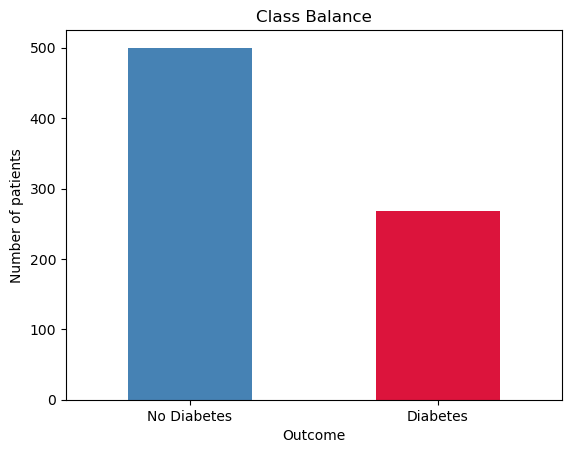

In [4]:
counts = df['Outcome'].value_counts()

print(f"No Diabetes: {counts[0]}  ({counts[0] / len(df):.1%})")
print(f"Diabetes:    {counts[1]}  ({counts[1] / len(df):.1%})")

counts.plot(kind='bar', color=['steelblue', 'crimson'])
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'], rotation=0)
plt.title('Class Balance')
plt.ylabel('Number of patients')
plt.show()


## Step 3: Explore the data visually (EDA)

We look at two things:
1. How each feature is distributed, split by class (does glucose look
   different for diabetic vs non-diabetic patients?)
2. How features correlate with each other

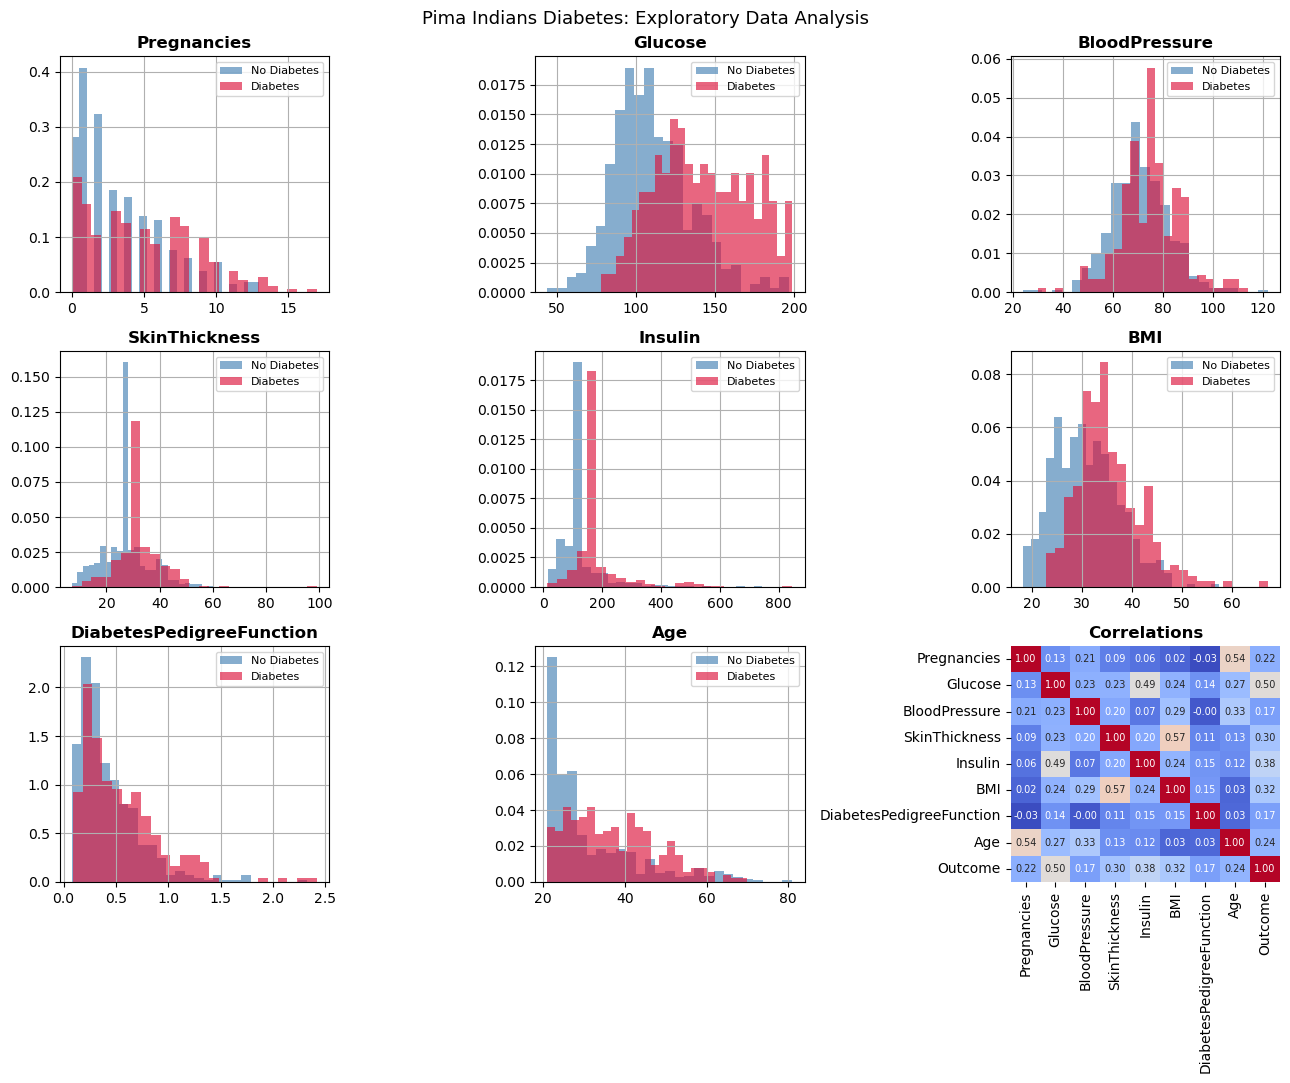

In [5]:
FEATURES = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(3, 3, figsize=(13, 11))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    df[df['Outcome'] == 0][col].hist(ax=axes[i], bins=25, alpha=0.65,
                                      color='steelblue', label='No Diabetes', density=True)
    df[df['Outcome'] == 1][col].hist(ax=axes[i], bins=25, alpha=0.65,
                                      color='crimson', label='Diabetes', density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[8], cbar=False, annot_kws={'size': 7})
axes[8].set_title('Correlations', fontweight='bold')

plt.suptitle('Pima Indians Diabetes: Exploratory Data Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('diabetes_eda.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 4: Fix impossible zero values

This dataset has a quirk: values like `Glucose = 0` or `BMI = 0` are not
real measurements, they are missing values that were recorded as `0`. A
living patient cannot have a glucose level or BMI of zero.

First, let's see how common this problem is.

In [6]:
ZERO_AS_MISSING = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print(f"{'Column':<20} {'Zero count':>10}  {'% of rows':>10}")
print("-" * 44)
for col in ZERO_AS_MISSING:
    n_zero = (df[col] == 0).sum()
    print(f"{col:<20} {n_zero:>10}  {n_zero / len(df) * 100:>9.1f}%")


Column               Zero count   % of rows
--------------------------------------------
Glucose                       0        0.0%
BloodPressure                 0        0.0%
SkinThickness                 0        0.0%
Insulin                       0        0.0%
BMI                           0        0.0%


We fix this by replacing each `0` with the **median** value for that
column, calculated separately for diabetic and non-diabetic patients. Using
the median (instead of the overall average) keeps the fix robust to
outliers, and calculating it per class keeps the signal that separates the
two groups intact.

In [7]:
df_clean = df.copy()

# Store the medians we use, we will need the same numbers later when
# making predictions on brand new patients.
train_medians = {}

for col in ZERO_AS_MISSING:
    for label in [0, 1]:
        real_values = df_clean.loc[(df_clean['Outcome'] == label) & (df_clean[col] > 0), col]
        median = real_values.median()
        mask = (df_clean[col] == 0) & (df_clean['Outcome'] == label)
        df_clean.loc[mask, col] = median
        print(f"{col} (class={label}): replaced {mask.sum()} zeros with {median:.1f}")

    # also keep an overall median per column, useful for single new patients
    # where we don't know the true class ahead of time
    train_medians[col] = float(df_clean.loc[df_clean[col] > 0, col].median())

print(f"\nZeros remaining: {(df_clean[ZERO_AS_MISSING] == 0).sum().sum()}")


Glucose (class=0): replaced 0 zeros with 107.0
Glucose (class=1): replaced 0 zeros with 140.0
BloodPressure (class=0): replaced 0 zeros with 70.0
BloodPressure (class=1): replaced 0 zeros with 74.5
SkinThickness (class=0): replaced 0 zeros with 27.0
SkinThickness (class=1): replaced 0 zeros with 32.0
Insulin (class=0): replaced 0 zeros with 102.5
Insulin (class=1): replaced 0 zeros with 169.5
BMI (class=0): replaced 0 zeros with 30.1
BMI (class=1): replaced 0 zeros with 34.3

Zeros remaining: 0


## Step 5: Feature engineering

With only 768 rows, a neural network has limited opportunity to discover
every useful pattern on its own. So we hand it a few features that
clinicians already know matter:

- **Glucose x BMI** and **Age x BMI**: these two factors together drive
  insulin resistance
- **impaired_glucose** / **diabetic_glucose**: standard clinical glucose
  thresholds
- **is_obese**: BMI >= 30 is the clinical definition of obesity
- **older_patient**: risk increases noticeably after age 40

In [8]:
df_feat = df_clean.copy()

df_feat['Glucose_x_BMI'] = df_feat['Glucose'] * df_feat['BMI']
df_feat['Age_x_BMI'] = df_feat['Age'] * df_feat['BMI']

df_feat['impaired_glucose'] = (df_feat['Glucose'] >= 100).astype(float)
df_feat['diabetic_glucose'] = (df_feat['Glucose'] >= 126).astype(float)
df_feat['is_obese'] = (df_feat['BMI'] >= 30).astype(float)
df_feat['older_patient'] = (df_feat['Age'] >= 40).astype(float)

FEATURE_COLS = [c for c in df_feat.columns if c != 'Outcome']
print(f"Total features: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

df_feat.head()


Total features: 14
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Glucose_x_BMI', 'Age_x_BMI', 'impaired_glucose', 'diabetic_glucose', 'is_obese', 'older_patient']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_x_BMI,Age_x_BMI,impaired_glucose,diabetic_glucose,is_obese,older_patient
0,6,148,72.0,35,169.5,33.6,0.627,50,1,4972.8,1680.0,1.0,1.0,1.0,1.0
1,1,85,66.0,29,102.5,26.6,0.351,31,0,2261.0,824.6,0.0,0.0,0.0,0.0
2,8,183,64.0,32,169.5,23.3,0.672,32,1,4263.9,745.6,1.0,1.0,0.0,0.0
3,1,89,66.0,23,94.0,28.1,0.167,21,0,2500.9,590.1,0.0,0.0,0.0,0.0
4,0,137,40.0,35,168.0,43.1,2.288,33,1,5904.7,1422.3,1.0,1.0,1.0,0.0


## Step 6: Split into train / validation / test

We split the data **before** scaling, and we use `stratify=y` so that all
three sets keep roughly the same proportion of diabetic vs non-diabetic
patients.

- **Train** (about 70%): what the model learns from
- **Validation** (about 15%): used during training to check progress and
  decide when to stop
- **Test** (about 15%): only touched once, at the very end, to report
  final performance

In [9]:
X = df_feat[FEATURE_COLS].values.astype(np.float32)
y = df_feat['Outcome'].values.astype(np.float32)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=RANDOM_SEED)

print(f"Train: {len(X_train):>4} rows  ({y_train.mean():.1%} positive)")
print(f"Val:   {len(X_val):>4} rows  ({y_val.mean():.1%} positive)")
print(f"Test:  {len(X_test):>4} rows  ({y_test.mean():.1%} positive)")


Train:  537 rows  (35.0% positive)
Val:    115 rows  (34.8% positive)
Test:   116 rows  (34.5% positive)


## Step 7: Scale the features

Neural networks train much better when every feature is on a similar
scale. We fit the scaler **only on the training data**, then apply that
same scaler to validation and test, this avoids leaking information from
validation/test into training.

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling done. Example, first row before and after:")
print("Before:", X_train[0][:5])
print("After: ", X_train_scaled[0][:5].round(2))


Scaling done. Example, first row before and after:
Before: [  1. 144.  82.  46. 180.]
After:  [-0.84  0.76  0.82  1.87  0.5 ]


## Step 8: Save everything for the next notebook

We save the prepared data in three formats, each for a different job:

- **CSV**: the scaled train/val/test tables, one row per patient, one
  column per feature plus `Outcome`. This is what the training notebook
  will load and feed straight into the ANN.
- **JSON**: lightweight, human-readable metadata (the feature names, the
  medians used for missing-value imputation, and the scaler's numbers).
  This is small enough to open in a text editor and is what we use later
  to scale a brand new patient by hand.
- **PKL**: one convenience file bundling everything above together
  (arrays, feature names, medians, and the actual fitted `scaler` object),
  in case you want to load it all in a single line.

In [11]:
import json

# --- CSV: scaled features + target, one file per split ---
train_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
train_df['Outcome'] = y_train

val_df = pd.DataFrame(X_val_scaled, columns=FEATURE_COLS)
val_df['Outcome'] = y_val

test_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS)
test_df['Outcome'] = y_test

train_df.to_csv('diabetes_train.csv', index=False)
val_df.to_csv('diabetes_val.csv', index=False)
test_df.to_csv('diabetes_test.csv', index=False)

print("Saved diabetes_train.csv", train_df.shape)
print("Saved diabetes_val.csv  ", val_df.shape)
print("Saved diabetes_test.csv ", test_df.shape)


Saved diabetes_train.csv (537, 15)
Saved diabetes_val.csv   (115, 15)
Saved diabetes_test.csv  (116, 15)


In [12]:
# --- JSON: feature names, medians, and the scaler's numbers ---
metadata = {
    'feature_cols': FEATURE_COLS,
    'train_medians': train_medians,
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
}

with open('diabetes_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved diabetes_metadata.json")


Saved diabetes_metadata.json


In [13]:
# --- PKL: one convenience bundle with everything, including the scaler object ---
prepared_data = {
    'X_train': X_train_scaled,
    'X_val': X_val_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    'scaler': scaler,
    'feature_cols': FEATURE_COLS,
    'train_medians': train_medians,
}

with open('diabetes_prepared.pkl', 'wb') as f:
    pickle.dump(prepared_data, f)

print("Saved diabetes_prepared.pkl")


Saved diabetes_prepared.pkl


The training notebook (`02_ann_training.ipynb`) loads the **CSV** files to
train the ANN, and the **JSON** file to scale new patients when making
predictions. The PKL file is there if you ever want everything in one
load.

### Done

We now have a clean, feature-engineered, scaled dataset saved to
`diabetes_prepared.pkl`.

Open **`02_ann_training.ipynb`** next to build and train the neural
network.